# ⚙️ Pré-processamento e Feature Engineering v2

Nesta segunda versão do pré-processamento, ampliei o conjunto de variáveis comportamentais para tentar melhorar a separação dos clusters.

Além das variáveis clássicas de RFM (Recency, Frequency e Monetary), serão criadas novas features relacionadas ao comportamento de compra dos clientes, como:

- Ticket médio
- Tempo de relacionamento
- Frequência normalizada no tempo

Também serão aplicados:
- Tratamento de outliers
- Transformação logarítmica
- Robust scaling

O objetivo é gerar uma base mais informativa para a clusterização com K-Means.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

sns.set(style="whitegrid")

In [2]:
df = pd.read_excel("../data/raw/customer_segmentation.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom


In [3]:
print("Shape inicial:", df.shape)

Shape inicial: (75000, 8)


## Limpeza inicial

Nesta etapa removemos registros que não podem ser utilizados para análise de comportamento do cliente:

- transações sem `CustomerID` - pode ser um problema se quiser posteriormente identificar qual cliente ficou em qual grupo
- devoluções (`Quantity <= 0`)
- preços inválidos (`UnitPrice <= 0`)

In [4]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Shape após limpeza:", df.shape)

Shape após limpeza: (54871, 8)


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(str)

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,20.40
1,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,27.80
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,2.60
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,5.85
4,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,19.90


In [7]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Data instantanea:", snapshot_date)

Data instantanea: 2011-12-10 12:50:00


## Criação das features por cliente

Serão calculadas as seguintes variáveis:

- **Recency**: dias desde a última compra
- **Frequency**: número de compras realizadas
- **Monetary**: valor total gasto
- **AvgTicket**: valor médio por compra
- **CustomerAge**: tempo desde a primeira compra
- **FreqPerDay**: frequência ajustada pelo tempo de relacionamento

In [8]:
recency = (
    df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

recency["Recency"] = (snapshot_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "Recency"]]

In [9]:
frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "Frequency"})
)

In [10]:
monetary = (
    df.groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index()
    .rename(columns={"TotalPrice": "Monetary"})
)

In [11]:
customer_age = (
    df.groupby("CustomerID")["InvoiceDate"]
    .min()
    .reset_index()
)

customer_age["CustomerAge"] = (snapshot_date - customer_age["InvoiceDate"]).dt.days
customer_age = customer_age[["CustomerID", "CustomerAge"]]

In [12]:
rfm_v2 = recency.merge(frequency, on="CustomerID")
rfm_v2 = rfm_v2.merge(monetary, on="CustomerID")
rfm_v2 = rfm_v2.merge(customer_age, on="CustomerID")

rfm_v2["AvgTicket"] = rfm_v2["Monetary"] / rfm_v2["Frequency"]
rfm_v2["FreqPerDay"] = rfm_v2["Frequency"] / rfm_v2["CustomerAge"]

rfm_v2.head()

,CustomerID,Recency,Frequency,Monetary,CustomerAge,AvgTicket,FreqPerDay
0,12346.0,326,1,77183.60,326,77183.600000,0.003067
1,12347.0,2,7,438.92,367,62.702857,0.019074
2,12348.0,319,2,443.52,358,221.760000,0.005587
3,12349.0,19,1,213.64,19,213.640000,0.052632
4,12350.0,310,1,42.90,310,42.900000,0.003226


In [13]:
rfm_v2.describe()

,Recency,Frequency,Monetary,CustomerAge,AvgTicket,FreqPerDay
count,3953.000000,3953.000000,3953.000000,3953.000000,3953.000000,3953.000000
mean,96.868201,3.586390,318.678680,217.668606,89.084000,0.023768
std,101.264983,6.149387,1756.727134,118.307442,1231.736082,0.047161
min,1.000000,1.000000,0.390000,1.000000,0.390000,0.002674
25%,20.000000,1.000000,42.600000,99.000000,27.751176,0.007194
50%,54.000000,2.000000,104.910000,242.000000,46.350000,0.013699
75%,155.000000,4.000000,255.560000,321.000000,76.170000,0.024291
max,374.000000,173.000000,77183.600000,374.000000,77183.600000,1.000000


In [14]:
rfm_v2.isnull().sum()

CustomerID     0
Recency        0
Frequency      0
Monetary       0
CustomerAge    0
AvgTicket      0
FreqPerDay     0
dtype: int64

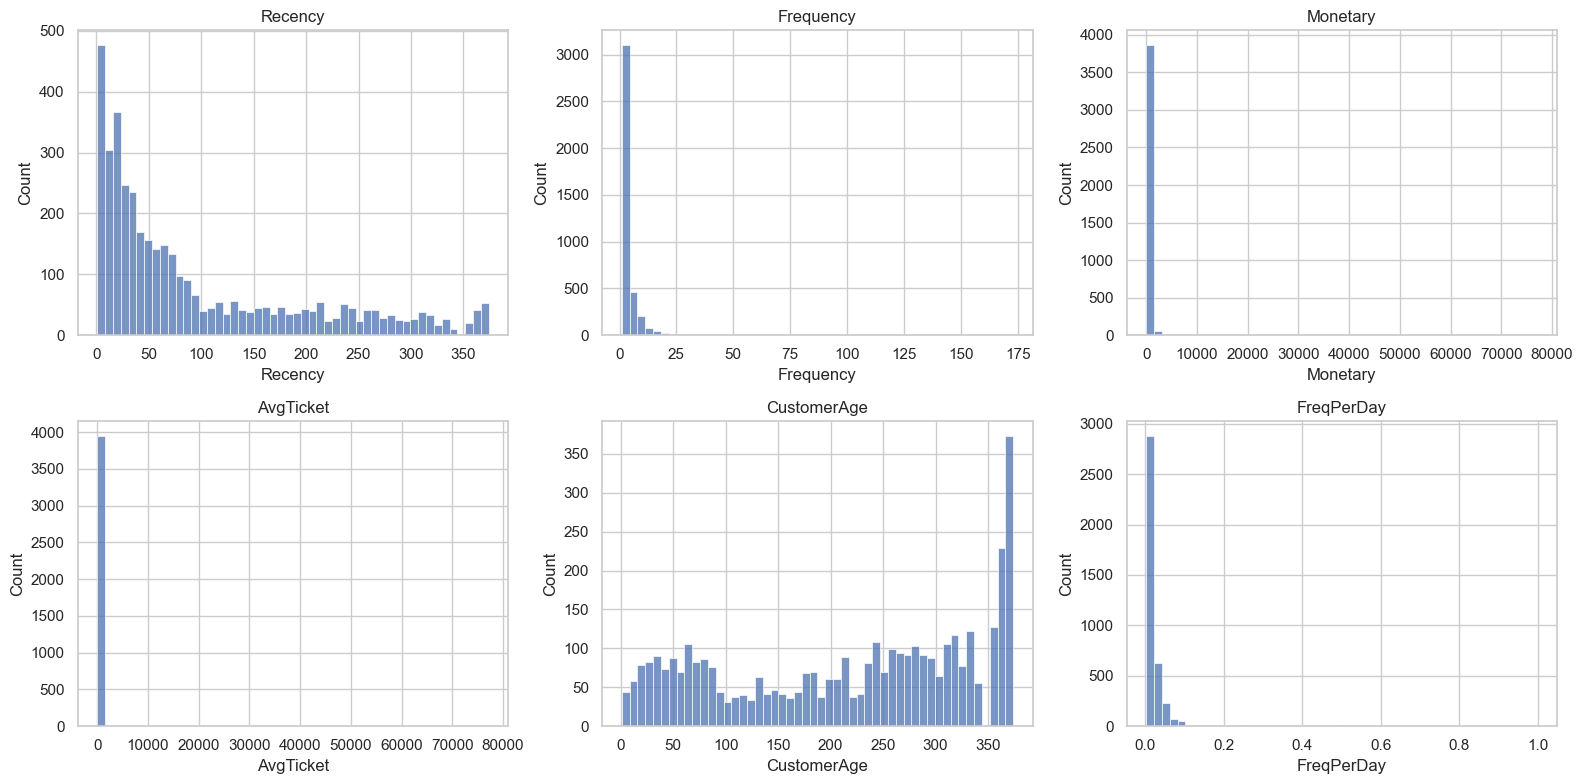

In [15]:
features_to_plot = ["Recency", "Frequency", "Monetary", "AvgTicket", "CustomerAge", "FreqPerDay"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(rfm_v2[col], bins=50, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Tratamento de outliers

Mesmo após a limpeza inicial, algumas variáveis ainda podem apresentar valores extremos que dificultam o funcionamento do K-Means.

Nesta versão, fiz um corte pelos quantis superiores para reduzir a influência de outliers extremos.

In [16]:
rfm_v2_filtered = rfm_v2.copy()

upper_quantile_cols = ["Monetary", "Frequency", "AvgTicket", "FreqPerDay"]

for col in upper_quantile_cols:
    upper_limit = rfm_v2_filtered[col].quantile(0.99)
    rfm_v2_filtered = rfm_v2_filtered[rfm_v2_filtered[col] <= upper_limit]

print("Shape após remoção de outliers:", rfm_v2_filtered.shape)

Shape após remoção de outliers: (3801, 7)


## Transformação logarítmica

Aplicado `log1p` para reduzir assimetria e tornar as distribuições mais adequadas para clustering.

In [17]:
rfm_v2_log = rfm_v2_filtered.copy()

log_cols = ["Recency", "Frequency", "Monetary", "AvgTicket", "CustomerAge", "FreqPerDay"]

for col in log_cols:
    rfm_v2_log[col] = np.log1p(rfm_v2_log[col])

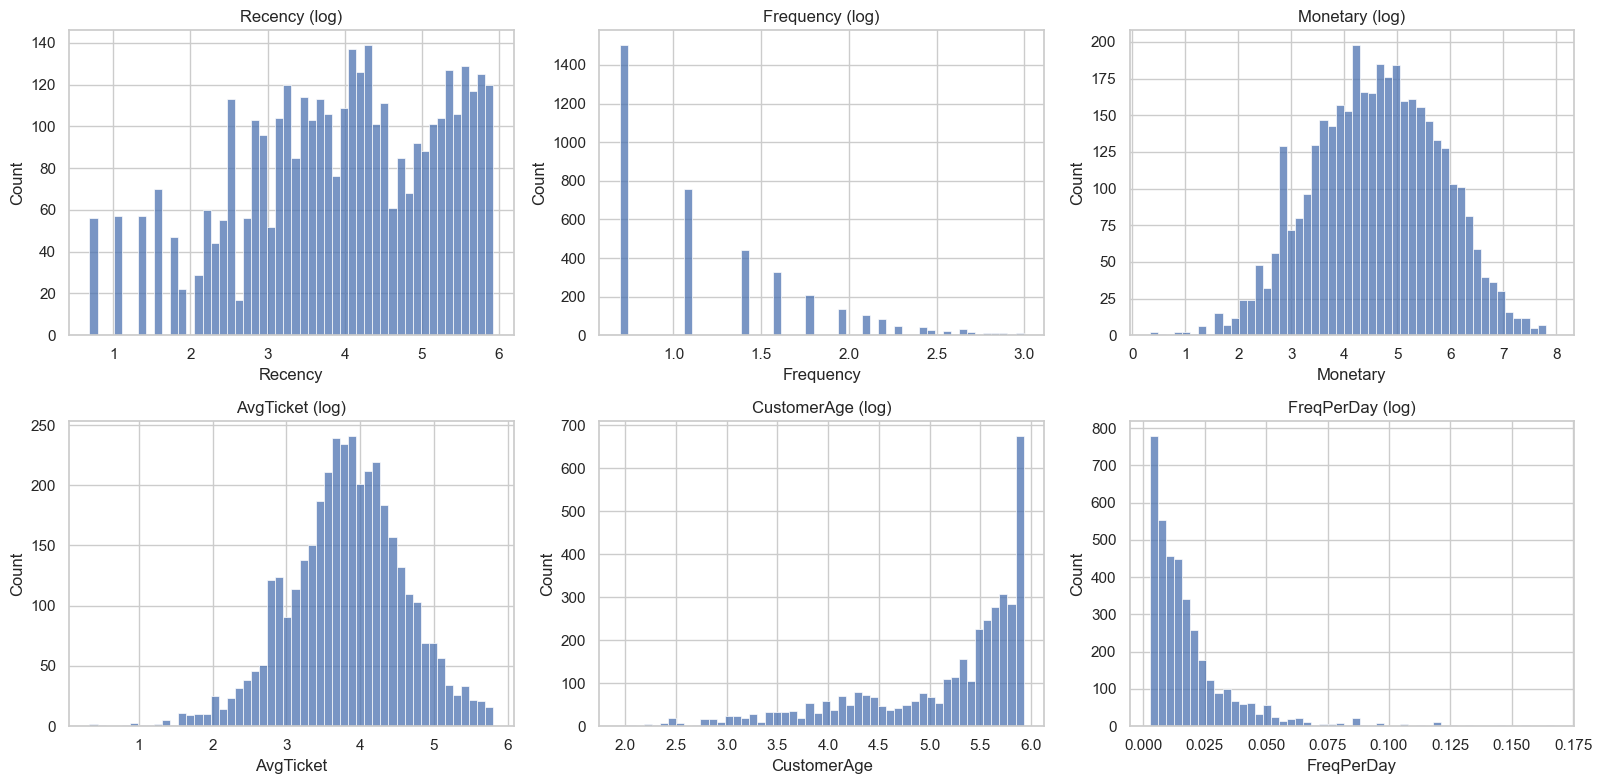

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    sns.histplot(rfm_v2_log[col], bins=50, ax=axes[i])
    axes[i].set_title(f"{col} (log)")

plt.tight_layout()
plt.show()

## Robust Scaling

Nesta versão utilizamos `RobustScaler`, que é menos sensível a outliers do que o `StandardScaler`.

In [19]:
scaler = RobustScaler()

feature_cols = ["Recency", "Frequency", "Monetary", "AvgTicket", "CustomerAge", "FreqPerDay"]

rfm_v2_scaled = scaler.fit_transform(rfm_v2_log[feature_cols])

processed_dataset_v2 = pd.DataFrame(rfm_v2_scaled, columns=feature_cols, index=rfm_v2_log.index)
processed_dataset_v2.insert(0, "CustomerID", rfm_v2_log["CustomerID"].values)

processed_dataset_v2.head()

,CustomerID,Recency,Frequency,Monetary,AvgTicket,CustomerAge,FreqPerDay
1,12347.0,-1.545807,1.070435,0.852389,0.328793,0.379357,0.359775
2,12348.0,0.877372,0.000000,0.858442,1.628178,0.356947,-0.502255
3,12349.0,-0.561364,-0.442507,0.434778,1.589635,-2.256536,2.456103
4,12350.0,0.862568,-0.442507,-0.488772,-0.057655,0.227043,-0.654334
5,12352.0,-0.242136,1.070435,0.797147,0.231651,0.188396,0.644571


In [20]:
processed_dataset_v2.describe()

,Recency,Frequency,Monetary,AvgTicket,CustomerAge,FreqPerDay
count,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,-0.059764,0.139506,-0.014064,-0.022112,-0.318847,0.352149
std,0.664301,0.619911,0.697949,0.807205,0.762059,1.237153
min,-1.756208,-0.442507,-2.497949,-3.641324,-3.206703,-0.689945
25%,-0.488840,-0.442507,-0.505446,-0.507887,-0.747137,-0.408660
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.511160,0.557493,0.494554,0.492113,0.252863,0.591340
max,0.959674,2.070435,1.936585,2.042990,0.396412,9.946149


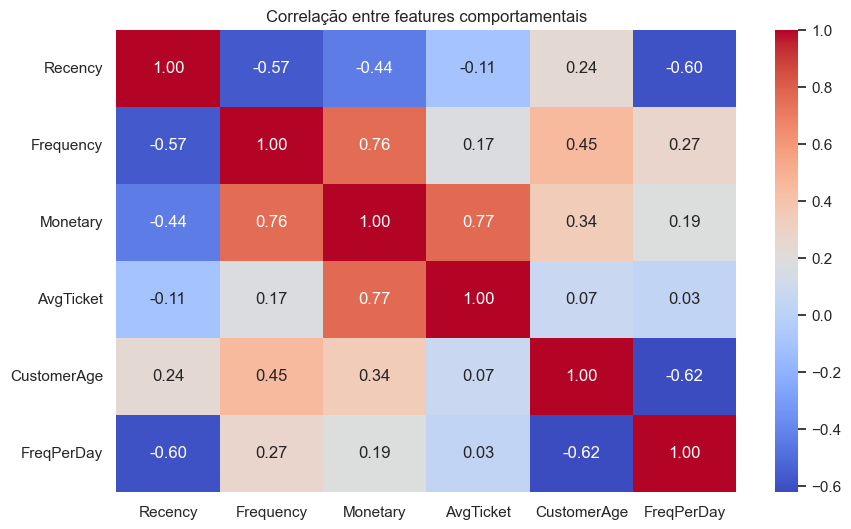

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(rfm_v2_log[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre features comportamentais")
plt.show()

In [23]:
project_root = Path.cwd().parent
output_path = project_root / "data" / "processed" / "processed_dataset_v2.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

processed_dataset_v2.to_csv(output_path, index=False)